In [2]:
###### LIBRARY IMPORTS ######
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torchaudio
import json
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import re
from pathlib import Path
from typing import Any, Dict, Iterable, Optional, Union
from SSM_model_V1 import SSMPhonemeModel as SSMPhonemeModelV1
from SSM_model_V2 import SSMPhonemeModel as SSMPhonemeModelV2
from SSM_model_V3 import SSMPhonemeModel as SSMPhonemeModelV3
from SSM_model_V4 import SSMPhonemeModel as SSMPhonemeModelV4
from SSM_model_V5 import SSMPhonemeModel as SSMPhonemeModelV5
from S2T_CNN_time import S2T_CNN_time_V1
from TIMITDataset import TIMITDataset
import random
from utils import build_phoneme_vocab, collate_fn_ctc, make_json_serializable, save_training_result, collate_fn_ctc_time_domain_padding, collate_fn_ctc_time_domain_features_during_training
from utils import ctc_greedy_decode, edit_distance, compute_batch_per_from_log_probs, decode_batch_to_phonemes, log_message, load_phoneme_intervals, calculate_phoneme_mel_statistics, ctc_greedy_decode_ids, align_phoneme_sequences
from functools import partial # for the new collate function
#import torch_xla
#import torch_xla.core.xla_model as xm

seed = 42 # define the seed for pytorch repeatability

In [1]:
###### DEFINE PATHS EITHER FOR GOOGLE COLAB OR LOCALLY ######
import sys
import os

colab = True # decides whether colab or local pc used

if colab:
    from google.colab import drive

    project_root_dir = os.getcwd() # get the root directory of the project
    data_root_dir = os.path.join(project_root_dir, "TIMIT") # define the path to the TIMIT dataset in colab
    drive.mount('/content/drive', force_remount=True) # mount the main drive directory to colab
    sys.path.append('/content/drive/MyDrive/thesis') # to import the SSM_TU directory we need its parent directory
    from SSM_TU.src.model.sequence_layer import SequenceLayer # import the SSM Layer directory
    vocab_root_dir = os.path.join(project_root_dir, "drive", "MyDrive", "thesis")

    # unzip the data
    if not os.path.exists("/content/TIMIT"):  # or your dataset folder
        !unzip -q /content/drive/MyDrive/thesis/TIMIT.zip -d /content/TIMIT
    else:
        print("TIMIT folder already exists in /content/TIMIT folder")

    base_results_dir = r"/content/drive/MyDrive/thesis/results"

    # check the content of the main directory
    print("TIMIT dataset contents")
    !ls /content/TIMIT
else:
    project_root_dir = os.getcwd() # get the root directory of the project
    vocab_root_dir = project_root_dir
    data_root_dir = project_root_dir
    base_results_dir = os.path.join(project_root_dir, "results")

vocabulary_dir = os.path.join(vocab_root_dir, "vocabulary")
train_data_csv = os.path.join(data_root_dir, "train_data.csv")
test_data_csv = os.path.join(data_root_dir, "test_data.csv")

print(f"Project root directory: {project_root_dir}")
print(f"Data root directory: {data_root_dir}")
print(f"Vocabulary directory: {vocabulary_dir}")
print(f"train_data.csv: {train_data_csv}")
print(f"test_data.csv: {test_data_csv}")




Mounted at /content/drive
TIMIT dataset contents
data	      README.DOC    test_data.csv  TIMITDIC.TXT
PHONCODE.DOC  SPKRINFO.TXT  TESTSET.DOC    train_data.csv
PROMPTS.TXT   SPKRSENT.TXT  TIMITDIC.DOC
Project root directory: /content
Data root directory: /content/TIMIT
Vocabulary directory: /content/drive/MyDrive/thesis/vocabulary
train_data.csv: /content/TIMIT/train_data.csv
test_data.csv: /content/TIMIT/test_data.csv


In [3]:
####### DEVICE SPECIFICATIONS ######

# GPU info (only works if CUDA runtime is active)
!nvidia-smi

complex_use = True  # MPS cannot handle complex tensors

print("PyTorch version:", torch.__version__)

# --- GPU / MPS checks ---
mps_available = torch.backends.mps.is_available()
cuda_available = torch.cuda.is_available()

print("MPS available:", mps_available)
print("MPS built:", torch.backends.mps.is_built())
print("CUDA available:", cuda_available)
print("CUDA built:", torch.backends.cuda.is_built())

# --- TPU check ---
tpu_available = False

#try:
#    tpu_available = True
#    tpu_device = xm.xla_device()
#    print("TPU detected:", tpu_device)

#except ImportError:
#    print("torch_xla not available → TPU not available")


# --- DEVICE SELECTION ---
if cuda_available:
    print("CUDA MEMORY")
    print("-----------")

    print(torch.cuda.get_device_name(0))
    print(f"Total memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    device = torch.device("cuda")
    print("🚀 Using GPU (CUDA)")
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print("Setting seed for cuda")

    torch.backends.cudnn.deterministic = True
    print("Cuda is deterministic")
    torch.backends.cudnn.benchmark = False
    print("Cuda benchmark = Fakse -> uses fixed algorithm") 
    torch.use_deterministic_algorithms(False) # if True, ctc doesnt work
#elif tpu_available:
#    device = tpu_device
#    print("🚀 Using TPU")
elif mps_available and not complex_use:
    device = torch.device("mps")
    print("🚀 Using GPU (MPS)")

else:
    device = torch.device("cpu")
    print("⚠️ Using CPU")

print("Final device:", device)

Fri Sep 18 15:32:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [8]:
###### CHECK THE OUTPUT OF THE torchaudio.load() method #####
test_waveform, test_sample_rate = torchaudio.load("/Users/atis/Desktop/MasterArbeit/Code/data/TEST/DR2/FDRD1/SA1.WAV")
features = mel_transform(test_waveform)
print("waveform 1 output:")
print("----------------")
print("Type of Waveform: ", type(test_waveform))
print("Shape of Waveform: ", test_waveform.shape)
print("Waveform:", test_waveform)

print("sample_rate 1 output:")
print("-------------------")
print("sample rate type:", type(test_sample_rate))
print("Sample rate:", test_sample_rate)

print("features 1 output:")
print("-------------------")
print("features type:", type(features))
print("features shape:", features.shape)

test_waveform, test_sample_rate = torchaudio.load("/Users/atis/Desktop/MasterArbeit/Code/data/TEST/DR2/FDRD1/SA2.WAV")
features = mel_transform(test_waveform)
print("waveform 2 output:")
print("----------------")
print("Type of Waveform: ", type(test_waveform))
print("Shape of Waveform: ", test_waveform.shape)
print("Waveform:", test_waveform)

print("sample_rate 2 output:")
print("-------------------")
print("sample rate type:", type(test_sample_rate))
print("Sample rate:", test_sample_rate)

print("features 2 output:")
print("-------------------")
print("features type:", type(features))
print("features shape:", features.shape)

waveform 1 output:
----------------
Type of Waveform:  <class 'torch.Tensor'>
Shape of Waveform:  torch.Size([1, 55911])
Waveform: tensor([[ 9.1553e-05,  6.1035e-05,  0.0000e+00,  ..., -6.1035e-05,
          6.1035e-05, -1.2207e-04]])
sample_rate 1 output:
-------------------
sample rate type: <class 'int'>
Sample rate: 16000
features 1 output:
-------------------
features type: <class 'torch.Tensor'>
features shape: torch.Size([1, 80, 350])
waveform 2 output:
----------------
Type of Waveform:  <class 'torch.Tensor'>
Shape of Waveform:  torch.Size([1, 47104])
Waveform: tensor([[ 1.5259e-04,  3.0518e-05, -3.0518e-05,  ..., -1.2207e-04,
          6.1035e-05, -6.1035e-05]])
sample_rate 2 output:
-------------------
sample rate type: <class 'int'>
Sample rate: 16000
features 2 output:
-------------------
features type: <class 'torch.Tensor'>
features shape: torch.Size([1, 80, 295])


In [4]:
####### LOAD VOCABULARY #######

# Select phoneme vocabulary version.
# Allowed values: 39 or 61
phoneme_set_version = 61

# ---------------------------------------------------------
# Validate phoneme set
# ---------------------------------------------------------
if phoneme_set_version not in {39, 61}:
    raise ValueError(
        f"Unsupported phoneme_set_version={phoneme_set_version}. "
        "Expected either 39 or 61."
    )

# ---------------------------------------------------------
# Define vocabulary filenames
# ---------------------------------------------------------
phoneme_to_idx_vocab_filename = (
    f"phoneme_to_idx_{phoneme_set_version}.json"
)

idx_to_phoneme_vocab_filename = (
    f"idx_to_phoneme_{phoneme_set_version}.json"
)

phoneme_to_idx_vocab_path = os.path.join(
    vocabulary_dir,
    phoneme_to_idx_vocab_filename
)


idx_to_phoneme_vocab_path = os.path.join(
    vocabulary_dir,
    idx_to_phoneme_vocab_filename
)

# ---------------------------------------------------------
# Check if the vocabulary files exist
# ---------------------------------------------------------
if not os.path.exists(phoneme_to_idx_vocab_path):
    raise FileNotFoundError(
        f"Vocabulary file not found:\n{phoneme_to_idx_vocab_path}"
    )

if not os.path.exists(idx_to_phoneme_vocab_path):
    raise FileNotFoundError(
        f"Vocabulary file not found:\n{idx_to_phoneme_vocab_path}"
    )

# ---------------------------------------------------------
# Load phoneme -> index vocabulary
# ---------------------------------------------------------
with open(phoneme_to_idx_vocab_path, "r", encoding="utf-8") as file:
    phoneme_to_idx_vocab = json.load(file)

# ---------------------------------------------------------
# Load index -> phoneme vocabulary
# ---------------------------------------------------------
with open(idx_to_phoneme_vocab_path, "r", encoding="utf-8") as file:
    idx_to_phoneme_vocab = json.load(file)

# JSON stores dictionary keys as strings, therefore convert them back to integers.
idx_to_phoneme_vocab = {
    int(idx): phoneme
    for idx, phoneme in idx_to_phoneme_vocab.items()
}

print(
    f"Successfully loaded the {phoneme_set_version}-phoneme vocabulary.\n"
    f"Vocabulary size (including CTC blank): {len(phoneme_to_idx_vocab)}"
)

Successfully loaded the 61-phoneme vocabulary.
Vocabulary size (including CTC blank): 62


In [ ]:
####### Training relevant objects ######
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

# The Mel spectrogram does the following:
#1. Split signal into windows
#2. Apply Fourier Transform (FFT)
#3. Convert frequencies to Mel scale
#4. Output energy per Mel band
mel_transform_n_mels = 80 # number of features in each timing window after transformation
mel_transform_nfft = 600
mel_transform_hop_length = 160
mel_transform_win_length = 600
mel_transform_sample_rate = 16000
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=mel_transform_sample_rate,
    n_fft=mel_transform_nfft, # FFT window size => how many samples are used for frequency analysis
    hop_length=mel_transform_hop_length, # step size between windows => at 16kHz a hop length of 160 means a stepsize of 10ms
    win_length=mel_transform_win_length, # Actual window size applied before FFT => at 16kHz a window size of 400 means 25ms window length
    n_mels=mel_transform_n_mels # Number of frequency bins after Mel conversion => number of frequency elements in each window AFTER conversion
)
batch_size = 8

# defining the model
ssm_vocab_size = len(phoneme_to_idx_vocab)
ssm_dropout = 0.0
ssm_num_layers = 3
ssm_model_version = "V4"

# Default values for parameters that only exist in some model versions
num_of_linear_layers = None
linear_in_features = None
linear_out_features = None
linear_dropout = None
last_linear_output = None


model_dict = {
    "model_type": "",
    "model_version": "",
}
#device = torch.device("cpu")
if ssm_model_version == "V1":
    ssm_d_in_d_out = mel_transform_n_mels
    d_in = ssm_d_in_d_out
    d_state = [256, 256, 256, 256]
    d_out = ssm_d_in_d_out
    
    ssm_model = SSMPhonemeModelV1(d_in=ssm_d_in_d_out,
                                  vocab_size=ssm_vocab_size,
                                  d_state=d_state,
                                  d_out=ssm_d_in_d_out,
                                  dropout=ssm_dropout).to(device=device)
    model_dict["model_type"] = "SSM"
    model_dict["model_version"] = ssm_model_version
    model_dict.update({
        "ssm_d_in": d_in,
        "ssm_d_state": d_state,
        "ssm_d_out": d_out,
    })
    
elif ssm_model_version == "V2":
    ssm_d_in_d_out = mel_transform_n_mels
    d_in = ssm_d_in_d_out
    d_state = 256
    d_out = ssm_d_in_d_out

    ssm_model = SSMPhonemeModelV2(d_in=d_in,
                                  vocab_size=ssm_vocab_size,
                                  d_state=d_state,
                                  dropout=ssm_dropout,
                                  num_layers=ssm_num_layers).to(device=device)
    model_dict["model_type"] = "SSM"
    model_dict["model_version"] = ssm_model_version
    model_dict.update({
        "ssm_d_in": d_in,
        "ssm_d_state": d_state,
        "ssm_d_out": d_out,
        "ssm_num_layers": ssm_num_layers
    })
    
elif ssm_model_version == "V3": # linear layer version
    ssm_d_in_d_out = [mel_transform_n_mels, 128, 192, 256]
    d_in = ssm_d_in_d_out
    d_state = [256, 256, 256, 256]
    d_out = ssm_d_in_d_out
    
    num_of_linear_layers = ssm_num_layers
    linear_in_features = ssm_d_in_d_out
    last_linear_output = 120
    linear_out_features = linear_in_features[1:] + [last_linear_output]
    linear_dropout = 0.1

    ssm_model = SSMPhonemeModelV3(d_state=d_state,
                                  d_in=d_in,
                                  d_out=d_out,
                                  num_of_ssm_layers=ssm_num_layers,
                                  linear_in_features=linear_in_features,
                                  linear_out_features=linear_out_features,
                                  num_of_linear_layers=num_of_linear_layers,
                                  vocab_size=ssm_vocab_size,
                                  ssm_dropout=ssm_dropout,
                                  linear_dropout=linear_dropout).to(device=device)
    
    model_dict["model_type"] = "SSM"
    model_dict["model_version"] = ssm_model_version
    model_dict.update({
        "ssm_d_in": d_in,
        "ssm_d_state": d_state,
        "ssm_d_out": d_out,
        "num_of_ssm_layers": ssm_num_layers,
        "num_of_linear_layers": num_of_linear_layers,
        "linear_in_features": ssm_num_layers,
        "last_linear_output": last_linear_output,
        "linear_out_features": linear_out_features,
        "linear_dropout": linear_dropout,
    })
    
elif ssm_model_version == "V4":
    d_in = [1, 128, 160]
    d_state = [128, 128, 128]
    d_out = [128, 160, 192]
    subsampling = [1,1,1]
    rzoh_probabilities = []
    
    linear_dropout = 0.2 # best -> 0.2

    norm = True
    norm_type = "bn"
    act = "LeakyRELu"
    trainable_SkipLayer=True

    ssm_model = SSMPhonemeModelV4(d_state=d_state,
                                  d_in=d_in,
                                  d_out=d_out,
                                  subsampling=subsampling,
                                  num_of_ssm_layers=ssm_num_layers,
                                  vocab_size=ssm_vocab_size,
                                  ssm_dropout=ssm_dropout,
                                  linear_dropout=linear_dropout,
                                  norm=norm,
                                  norm_type=norm_type,
                                  act=act,
                                  trainable_SkipLayer=trainable_SkipLayer,
                                  rzoh_probabilities=rzoh_probabilities).to(device=device)
    model_dict["model_type"] = "SSM"
    model_dict["model_version"] = ssm_model_version
    model_dict.update({
        "ssm_d_in": d_in,
        "ssm_d_state": d_state,
        "ssm_d_out": d_out,
        "num_of_ssm_layers": ssm_num_layers,
        "linear_dropout": linear_dropout,
        "norm": norm,
        "ssm_dropout": ssm_dropout,
        "norm_type": norm_type,
        "act": act,
        "trainable_SkipLayer": trainable_SkipLayer,
        "rzoh_probabilities": rzoh_probabilities,
    })

elif ssm_model_version == "V5":
    # ---------------------------------------------------------
    # Convolutional frontend configuration
    # ---------------------------------------------------------
    num_conv_layers = 1
    raw_input_channel = 1

    # One learned feature vector with 64 elements is created
    # at every output timestep of the convolutional frontend.
    conv_out_channels = [64]

    # At 16 kHz:
    # kernel_size=400 corresponds to 25 ms.
    # stride=160 corresponds to a 10 ms step.
    conv_kernel_sizes = [400]
    conv_strides = [160]
    conv_paddings = [200]
    conv_dilations = [1]

    # Bias is unnecessary -> BatchNorm follows Conv1d.
    conv_bias = False
    conv_batch_norm = True

    # ---------------------------------------------------------
    # SSM configuration
    # ---------------------------------------------------------
    # The first SSM input dimension must equal the number of
    # output channels of the final convolutional layer:
    #
    # d_in[0] == conv_out_channels[-1]
    d_in = [64, 64, 96, 128]
    d_state = [128, 128, 128, 128]
    d_out = [64, 96, 128, 192]

    linear_dropout = 0.1

    norm = True
    norm_type = "bn"
    act = "LeakyRELu"
    trainable_SkipLayer = True

    # ---------------------------------------------------------
    # Create model
    # ---------------------------------------------------------
    ssm_model = SSMPhonemeModelV5(
        d_state=d_state,
        d_in=d_in,
        d_out=d_out,
        num_of_ssm_layers=ssm_num_layers,
        vocab_size=ssm_vocab_size,

        ssm_dropout=ssm_dropout,
        linear_dropout=linear_dropout,
        norm=norm,
        norm_type=norm_type,
        act=act,
        trainable_SkipLayer=trainable_SkipLayer,

        num_conv_layers=num_conv_layers,
        raw_input_channel=raw_input_channel,
        conv_out_channels=conv_out_channels,
        conv_kernel_sizes=conv_kernel_sizes,
        conv_strides=conv_strides,
        conv_paddings=conv_paddings,
        conv_dilations=conv_dilations,
        conv_bias=conv_bias,
        conv_batch_norm=conv_batch_norm
    ).to(device=device)

    # ---------------------------------------------------------
    # Save model configuration
    # ---------------------------------------------------------
    model_dict["model_type"] = "Conv_+_SSM"
    model_dict["model_version"] = ssm_model_version

    model_dict.update({
        # SSM parameters
        "ssm_d_in": d_in,
        "ssm_d_state": d_state,
        "ssm_d_out": d_out,
        "num_of_ssm_layers": ssm_num_layers,
        "ssm_dropout": ssm_dropout,
        "linear_dropout": linear_dropout,
        "norm": norm,
        "norm_type": norm_type,
        "act": act,
        "trainable_SkipLayer": trainable_SkipLayer,

        # Convolutional frontend parameters
        "num_conv_layers": num_conv_layers,
        "raw_input_channel": raw_input_channel,
        "conv_out_channels": conv_out_channels,
        "conv_kernel_sizes": conv_kernel_sizes,
        "conv_strides": conv_strides,
        "conv_paddings": conv_paddings,
        "conv_dilations": conv_dilations,
        "conv_bias": conv_bias,
        "conv_batch_norm": conv_batch_norm,
    })

elif ssm_model_version == "CNN_time_domain_V1":
    in_channels = [1, 32, 64, 128, 256]
    out_channels = [32, 64, 128, 256, 512]
    lin_dropout = 0.3
    kernel_size=5
    padding=2,
    padding_type="non-causal"
    stride=1

    ssm_model = S2T_CNN_time_V1(vocab_size=ssm_vocab_size,
                                kernel_size=kernel_size,
                                padding=padding,
                                padding_type=padding_type,
                                stride=stride,
                                in_channels=in_channels,
                                out_channels=out_channels,
                                lin_dropout=lin_dropout
                                ).to(device=device)
    
    model_dict["model_type"] = "CNN"
    model_dict["model_version"] = ssm_model_version
    model_dict.update({
        "in_channels": in_channels,
        "out_channels": out_channels,
        "ssm_dropout": ssm_dropout,
        "linear_dropout": lin_dropout,
        "kernel_size": kernel_size,
        "padding": padding,
        "padding_type": padding_type,
        "stride": stride,
    })
    

# CTC loss function
ctc_zero_infinity = True
loss_fn = nn.CTCLoss(blank=0,
                     zero_infinity=ctc_zero_infinity) # to nullyify the infinity effects of possible very short sequences

# optimizer
optimizer_type = "AdamW"
optimizer_dict = {}
if optimizer_type == "Adam":
    opt_Adam_lr = 0.001
    opt_Adam_weight_decay = 1e-4
    optimizer = torch.optim.Adam(
        params=ssm_model.parameters(),
        lr = opt_Adam_lr,
        weight_decay=opt_Adam_weight_decay)
    
    
    optimizer_dict = {
        "type": optimizer_type,
        "learning_rate": opt_Adam_lr,
        "weight_decay": opt_Adam_weight_decay,
    }

elif optimizer_type == "AdamW":
    opt_AdamW_other_layer_weight_decay = 0.01
    opt_AdamW_ssm_layer_weight_decay = 0
    
    opt_AdamW_lr = 5e-4
    opt_AdamW_ssm_lr_factor = 1
    opt_AdamW_other_lr_factor = 4

    params_ssm_lr = [param for name, param in ssm_model.named_parameters() if 'B' in name or 'C' in name or 'Lambda' in name or 'log_step' in name] # parameters of the sequence layers
    params_other_lr = [param for name, param in ssm_model.named_parameters() if 'B' not in name and 'C' not in name and 'Lambda' not in name and 'log_step' not in name] # parameters of other layers like the Linear Decoder

    optimizer_dict = {
        "type": optimizer_type,
        "learning_rate": opt_AdamW_lr,
        "ssm_lr_factor": opt_AdamW_ssm_lr_factor,
        "other_lr_factor": opt_AdamW_other_lr_factor,
        "ssm_weight_decay": opt_AdamW_ssm_layer_weight_decay,
        "other_weight_decay": opt_AdamW_other_layer_weight_decay,
    }


    optimizer = torch.optim.AdamW([
            {'params': params_ssm_lr, 'lr':opt_AdamW_ssm_lr_factor * opt_AdamW_lr, 'weight_decay': opt_AdamW_ssm_layer_weight_decay},
            {'params': params_other_lr, 'lr': opt_AdamW_other_lr_factor * opt_AdamW_lr, 'weight_decay': opt_AdamW_other_layer_weight_decay},
        ], 
    lr=opt_AdamW_lr, weight_decay=opt_AdamW_other_layer_weight_decay) # default values for lr and weight decay

print(f"✅ {ssm_model_version} model is used")

# Scheduler
scheduler_type = "ReduceLROnPlateau"

StepLR_scheduler_step_size = 25
StepLR_scheduler_gamma = 0.5

plateau_scheduler_mode = "min"
plateau_scheduler_factor = 0.3
plateau_scheduler_patience = 3
plateau_scheduler_threshold = 1e-3
plateau_scheduler_minlr = 1e-5

if scheduler_type == "StepLR":
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer=optimizer,
                                                step_size=StepLR_scheduler_step_size,
                                                gamma=StepLR_scheduler_gamma)
    print("✅ StepLR scheduler is used")

elif scheduler_type == "ReduceLROnPlateau":
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode=plateau_scheduler_mode,
        factor=plateau_scheduler_factor,
        patience=plateau_scheduler_patience,
        threshold=plateau_scheduler_threshold,
        min_lr=plateau_scheduler_minlr
    )
    print("✅ ReduceLROnPlateu scheduler is used")

# Gradient clipping
use_gradient_clipping = True


✅ V4 model is used
✅ ReduceLROnPlateu scheduler is used


In [6]:
####### DATASETS and DATALOADERS #######

padding_after_mel_transform = False
use_time_domain_features = True
collate_function = ""
if padding_after_mel_transform:
    dataloader_collate_fn = collate_fn_ctc
    collate_function = "collate_fn_ctc"
else:
    # creating the partial function to be able to set the collate_fn with more parameters in the dataloader
    if use_time_domain_features:
        dataloader_collate_fn = collate_fn_ctc_time_domain_features_during_training
        collate_function = "collate_fn_ctc_time_domain_features_during_training"
    else:
        dataloader_collate_fn = partial(
            collate_fn_ctc_time_domain_padding,
            mel_transform=mel_transform,
            hop_length=mel_transform_hop_length
        )
        collate_function = "collate_fn_ctc_time_domain_padding"

train_dataset = TIMITDataset(
    csv_file=train_data_csv,
    train_or_test="TRAIN",
    root_dir=project_root_dir,
    phoneme_to_idx_vocab=phoneme_to_idx_vocab,
    transform=None,
)

val_dataset = TIMITDataset(
    csv_file=test_data_csv,
    train_or_test="TEST",
    root_dir=project_root_dir,
    phoneme_to_idx_vocab=phoneme_to_idx_vocab,
    transform=None,
)

g = torch.Generator()
g.manual_seed(seed)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=dataloader_collate_fn,
    generator=g

)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=dataloader_collate_fn
)

print("CUDA Memory Summary")
print("-------------------")
if cuda_available:
    print(torch.cuda.memory_summary())

TRAIN Dataset creation process...
Filtering dataframe to only include TRAIN samples
Checked -> whole dataset belongs to TRAIN
Creating cache directory
Creating the samples dictionary...
Load the waveforms...
Pad the time domain tensors...
100/4620 waveforms padded
200/4620 waveforms padded
300/4620 waveforms padded
400/4620 waveforms padded
500/4620 waveforms padded
600/4620 waveforms padded
700/4620 waveforms padded
800/4620 waveforms padded
900/4620 waveforms padded
1000/4620 waveforms padded
1100/4620 waveforms padded
1200/4620 waveforms padded
1300/4620 waveforms padded
1400/4620 waveforms padded
1500/4620 waveforms padded
1600/4620 waveforms padded
1700/4620 waveforms padded
1800/4620 waveforms padded
1900/4620 waveforms padded
2000/4620 waveforms padded
2100/4620 waveforms padded
2200/4620 waveforms padded
2300/4620 waveforms padded
2400/4620 waveforms padded
2500/4620 waveforms padded
2600/4620 waveforms padded
2700/4620 waveforms padded
2800/4620 waveforms padded
2900/4620 wave

In [19]:
####### TESTING THE SHAPES OF ONE BATCH ######
batch = next(iter(train_dataloader))
features, feature_lengths, labels, label_lengths = batch

print("features shape:",features.shape)
print("features_length:",feature_lengths.shape)
print("labels shape:",labels.shape)
print("labels length:",label_lengths.shape)
print("length of training dataset:",len(train_dataset))
print("length of validation dataset:", len(val_dataset))

features shape: torch.Size([8, 779, 80])
features_length: torch.Size([8])
labels shape: torch.Size([342])
labels length: torch.Size([8])
length of training dataset: 4620
length of validation dataset: 1680


In [7]:
######## CHECKPOINT handling and function for checking nan/infinity values in case of exploding gradients #######
def load_model_from_checkpoint(use_scheduler: bool) -> tuple:
    """Loads the model from the last saved checkpoint
    
    Parameters
    ----------
    use_scheduler: bool
        To decide whether scheduler was used or not

    Returns
    -------
    tuple: 
        0. element: start_epoch
        1. element train_epoch_losses
        2. element val_epoch_losses
    """
    checkpoint = torch.load("checkpoint.pt", map_location=device)

    ssm_model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if use_scheduler:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1

    train_epoch_losses = checkpoint.get("train_epoch_losses",[])
    val_epoch_losses = checkpoint.get("val_epoch_losses",[])
    train_epoch_PERs = checkpoint.get("train_epoch_PERs", [])
    val_epoch_PERs = checkpoint.get("val_epoch_PERs", [])

    return start_epoch, train_epoch_losses, val_epoch_losses, train_epoch_PERs, val_epoch_PERs

def create_checkpoint(epoch: int,
                      use_scheduler: bool,
                      train_epoch_losses: list,
                      val_epoch_losses: list,
                      train_epoch_PERs: list,
                      val_epoch_PERs: list) -> None:
    """Creates a Checkpoint to save the current status and informations about the trained model
    
    Parameters
    ----------
    epoch: int
        The current epoch
    
    use_scheduler: bool
        To decide whether scheduler was used or not
    
    train_epoch_losses: list
        The list of the training epoch losses until this point
    
    val_epoch_losses: list
        The list of the validation epoch losses until this point

    Returns
    -------
    None
    """
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": ssm_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if use_scheduler else None,
        "train_epoch_losses": train_epoch_losses,
        "val_epoch_losses": val_epoch_losses,
        "train_epoch_PERs": train_epoch_PERs,
        "val_epoch_PERs": val_epoch_PERs,

    }

    torch.save(checkpoint, f"checkpoint.pt")

def check_finite_tensor(tensor, name: str):
    if not torch.isfinite(tensor).all():
        raise RuntimeError(
            f"Non-finite values detected in {name}. "
            f"min={tensor.nan_to_num().min().item():.4f}, "
            f"max={tensor.nan_to_num().max().item():.4f}"
        )

In [8]:
###### Training and Validation loop with optional PER ######

training_start_time = time.time()

epochs = 20
use_scheduler = True
compute_per = False   # set to False to skip PER computation and PER logging for saving time
resume_from_checkpoint = False

use_early_stopping = True

early_stopping_patience = 8
early_stopping_min_delta = 1e-4

best_val_loss = float("inf")
best_epoch = -1
epochs_without_improvement = 0

best_model_path = "best_model_state_dict.pt"

print("device: ", device)
print("batch_size: ",batch_size)
print("ssm model version:", ssm_model_version)
print("number of ssm layers:", ssm_num_layers)
print("Scheduler: ", scheduler_type)
print("Use Checkpoint: ", resume_from_checkpoint)

blank_idx = 0   # CTC blank index

if resume_from_checkpoint:
    (start_epoch,
     train_epoch_losses,
     val_epoch_losses,
     train_epoch_PERs,
     val_epoch_PERs
    ) = load_model_from_checkpoint(use_scheduler=use_scheduler)
    
    file_mode = "a"
else:
    start_epoch = 0
    train_epoch_losses = []
    val_epoch_losses = []
    train_epoch_PERs = []
    val_epoch_PERs = []

    file_mode="w"

log_file_loss_and_PER_path = "training_log_loss_and_PER.txt"
log_file_predictions_path = "training_log_predictions.txt"
log_file_loss_and_PER = open(log_file_loss_and_PER_path, file_mode)
log_file_predictions = open(log_file_predictions_path, file_mode)

for epoch in range(start_epoch, epochs):
    true_train_batch_loss = 0.0
    epoch_train_loss = 0.0

    true_val_batch_loss = 0.0
    epoch_val_loss = 0.0

    total_train_edit_distance = 0
    total_train_target_length = 0
    epoch_train_per = None

    total_val_edit_distance = 0
    total_val_target_length = 0
    epoch_val_per = None

    ##### TRAINING #####
    ssm_model.train()

    for batch, (X_train, X_train_length, y_train, y_train_length) in enumerate(train_dataloader):
        # send tensors to device
        X_train = X_train.to(device)
        y_train = y_train.to(device)

        # forward pass
        logits = ssm_model(X_train)                    # [B, T, C]
        log_probs = logits.log_softmax(dim=-1)        # [B, T, C]
        log_probs_ctc = log_probs.transpose(0, 1)     # [T, B, C]

        #checking exploding gradients for the log probabilities
        check_finite_tensor(log_probs, "log_probs")

        # Convert original waveform lengths into lengths after all Conv1d layers.
        if ssm_model_version == "V5":
            X_train_length = ssm_model.calculate_output_lengths(
                X_train_length
            )

        # loss
        loss = loss_fn(log_probs_ctc, y_train, X_train_length, y_train_length)

        # checking exploding gradients for the loss
        check_finite_tensor(loss, "loss")

        # accumulate weighted epoch loss
        true_train_batch_loss += loss.item() * len(X_train)

        # compute PER for this batch only if enabled
        if compute_per and (epoch == 0 or (epoch + 1) % 10 == 0):
            batch_train_per, batch_train_edits, batch_train_targets = compute_batch_per_from_log_probs(
                log_probs=log_probs,
                input_lengths=X_train_length,
                targets=y_train,
                target_lengths=y_train_length,
                blank_idx=blank_idx
            )

            total_train_edit_distance += batch_train_edits
            total_train_target_length += batch_train_targets

        # backward
        optimizer.zero_grad()
        loss.backward()

        if use_gradient_clipping:
            torch.nn.utils.clip_grad_norm_(
            ssm_model.parameters(),
            max_norm=1.0
)

        optimizer.step()

        if batch % 30 == 0: # calculate PER value in the first and last epoch
            if compute_per and (epoch == 0 or (epoch + 1) % 10 ==0):
                log_message(
                    f"Training batch: {batch + 1}/{len(train_dataloader)} | "
                    f"Batch loss: {loss.item():.4f} | "
                    f"Batch PER: {batch_train_per * 100:.2f}%",
                    log_file_loss_and_PER
                )
            else:
                log_message(
                    f"Training batch: {batch + 1}/{len(train_dataloader)} | "
                    f"Batch loss: {loss.item():.4f}",
                    log_file_loss_and_PER
                )

    epoch_train_loss = true_train_batch_loss / len(train_dataset)

    if compute_per and (epoch == 0 or (epoch + 1) % 10 == 0):
        epoch_train_per = (
            total_train_edit_distance / total_train_target_length
            if total_train_target_length > 0 else 0.0
        )
        train_epoch_PERs.append(epoch_train_per)
    else:
        train_epoch_PERs.append(None)

    train_epoch_losses.append(epoch_train_loss)

    ##### VALIDATION #####
    ssm_model.eval()

    with torch.inference_mode():
        for batch, (X_val, X_val_length, y_val, y_val_length) in enumerate(val_dataloader):
            # send tensors to device
            X_val = X_val.to(device)
            y_val = y_val.to(device)

            # forward pass
            logits = ssm_model(X_val)                  # [B, T, C]
            log_probs = logits.log_softmax(dim=-1)    # [B, T, C]
            log_probs_ctc = log_probs.transpose(0, 1) # [T, B, C]

            # Convert original waveform lengths into lengths after all Conv1d layers.
            if ssm_model_version == "V5":
                X_val_length = ssm_model.calculate_output_lengths(
                    X_val_length
                )

            # loss
            loss = loss_fn(log_probs_ctc, y_val, X_val_length, y_val_length)

            # accumulate weighted epoch loss
            true_val_batch_loss += loss.item() * len(X_val)

            # compute PER for this batch only if enabled
            if compute_per and (epoch == 0 or (epoch + 1) % 10 == 0):
                batch_val_per, batch_val_edits, batch_val_targets = compute_batch_per_from_log_probs(
                    log_probs=log_probs,
                    input_lengths=X_val_length,
                    targets=y_val,
                    target_lengths=y_val_length,
                    blank_idx=blank_idx
                )

                total_val_edit_distance += batch_val_edits
                total_val_target_length += batch_val_targets

            if batch % 15 == 0: # calculate PER value in the first and last epoch
                if compute_per and (epoch == 0 or (epoch + 1) % 10 == 0):
                    log_message(
                        f"Validation batch: {batch + 1}/{len(val_dataloader)} | "
                        f"Batch loss: {loss.item():.4f} | "
                        f"Batch PER: {batch_val_per * 100:.2f}%",
                        log_file_loss_and_PER
                    )
                else:
                    log_message(
                        f"Validation batch: {batch + 1}/{len(val_dataloader)} | "
                        f"Batch loss: {loss.item():.4f}",
                        log_file_loss_and_PER
                    )

    epoch_val_loss = true_val_batch_loss / len(val_dataset)

    if compute_per and (epoch == 0 or (epoch + 1) % 10 ==0):
        epoch_val_per = (
            total_val_edit_distance / total_val_target_length
            if total_val_target_length > 0 else 0.0
        )
        val_epoch_PERs.append(epoch_val_per)
    else:
        val_epoch_PERs.append(None)

    val_epoch_losses.append(epoch_val_loss)

    ##### EARLY STOPPING #####
    should_stop_early = False

    if use_early_stopping:
        improvement = best_val_loss - epoch_val_loss

        if improvement > early_stopping_min_delta:
            best_val_loss = epoch_val_loss
            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(
                ssm_model.state_dict(),
                best_model_path
            )

            log_message(
                f"Validation loss improved to {best_val_loss:.6f}. "
                f"Best model saved at epoch {epoch + 1}.",
                log_file_loss_and_PER
            )

        else:
            epochs_without_improvement += 1

            log_message(
                f"No sufficient validation improvement for "
                f"{epochs_without_improvement}/"
                f"{early_stopping_patience} epochs.",
                log_file_loss_and_PER
            )

            if epochs_without_improvement >= early_stopping_patience:
                should_stop_early = True

    # use scheduler LRStepScheduler if use_scheduler is True
    if use_scheduler:
        if scheduler_type == "StepLR":
            scheduler.step()
        elif scheduler_type == "ReduceLROnPlateau":
            scheduler.step(epoch_val_loss)
        print("LR:", optimizer.param_groups[0]["lr"])

    # Create checkpoint after every epoch so be able to restart if something went wrong
    create_checkpoint(epoch=epoch,
                      use_scheduler=use_scheduler,
                      train_epoch_losses=train_epoch_losses,
                      val_epoch_losses=val_epoch_losses,
                      train_epoch_PERs=train_epoch_PERs,
                      val_epoch_PERs=val_epoch_PERs)

    log_message("-------------------------------------------------------------------------------------------------------", log_file_loss_and_PER)

    if compute_per and (epoch == 0 or (epoch + 1) % 10 == 0):
        log_message(
            f"Epoch: {epoch + 1} | Training loss: {epoch_train_loss:.6f} | Training PER: {epoch_train_per * 100:.2f}%",
            log_file_loss_and_PER
        )
        log_message(
            f"Epoch: {epoch + 1} | Validation loss: {epoch_val_loss:.6f} | Validation PER: {epoch_val_per * 100:.2f}%",
            log_file_loss_and_PER
        )
    else:
        log_message(
            f"Epoch: {epoch + 1} | Training loss: {epoch_train_loss:.6f}",
            log_file_loss_and_PER
        )
        log_message(
            f"Epoch: {epoch + 1} | Validation loss: {epoch_val_loss:.6f}",
            log_file_loss_and_PER
        )

    log_message("-------------------------------------------------------------------------------------------------------", log_file_loss_and_PER)

    ##### QUALITATIVE VALIDATION PREDICTIONS EVERY 10 EPOCHS #####
    if (epoch + 1) % 10 == 0:
        log_message(f"########## QUALITATIVE VALIDATION CHECK AFTER EPOCH {epoch + 1} ##########", log_file_predictions)

        ssm_model.eval()
        with torch.inference_mode():
            # take one batch from validation loader
            X_obs, X_obs_length, y_obs, y_obs_length = next(iter(val_dataloader))

            X_obs = X_obs.to(device)
            y_obs = y_obs.to(device)

            logits_obs = ssm_model(X_obs)
            log_probs_obs = logits_obs.log_softmax(dim=-1)

            decoded_examples = decode_batch_to_phonemes(
                log_probs=log_probs_obs,
                input_lengths=X_obs_length,
                targets=y_obs,
                target_lengths=y_obs_length,
                idx_to_phoneme=idx_to_phoneme_vocab,
                blank_idx=blank_idx
            )

            # show only a few examples
            for i in range(min(5, len(decoded_examples))):
                pred_phonemes, tgt_phonemes = decoded_examples[i]

                log_message(f"Example {i + 1}", log_file_predictions)
                log_message(f"PRED: {' '.join(pred_phonemes)}", log_file_predictions)
                log_message(f"TGT : {' '.join(tgt_phonemes)}", log_file_predictions)
                log_message("--------------------------------------------------", log_file_predictions)
    
    if should_stop_early:
        log_message(
            f"Early stopping triggered after epoch {epoch + 1}. "
            f"Best epoch was {best_epoch + 1} "
            f"with validation loss {best_val_loss:.6f}.",
            log_file_loss_and_PER
        )

        log_message(
            f"Early stopping triggered after epoch {epoch + 1}. "
            f"Best epoch was {best_epoch + 1}.",
            log_file_predictions
        )

        break

##### RESTORE BEST MODEL #####
if use_early_stopping and best_epoch >= 0:
    best_state_dict = torch.load(
        best_model_path,
        map_location=device
    )

    ssm_model.load_state_dict(best_state_dict)

    print(
        f"Best model restored from epoch {best_epoch + 1} "
        f"with validation loss {best_val_loss:.6f}"
    )

training_end_time = time.time()
elapsed_time = (training_end_time - training_start_time) / 60
log_message(f"Total training and validation time is: {elapsed_time:.2f} minutes", log_file_loss_and_PER)
log_message(f"Total training and validation time is: {elapsed_time:.2f} minutes", log_file_predictions)

# close the file handlers of the log files
log_file_loss_and_PER.close()
log_file_predictions.close()

device:  cuda
batch_size:  8
ssm model version: V4
number of ssm layers: 3
Scheduler:  ReduceLROnPlateau
Use Checkpoint:  False
Training batch: 1/578 | Batch loss: 4721.0547
Training batch: 31/578 | Batch loss: 1987.9415
Training batch: 61/578 | Batch loss: 479.9335
Training batch: 91/578 | Batch loss: 709.4729
Training batch: 121/578 | Batch loss: 1056.4323
Training batch: 151/578 | Batch loss: 115.5930
Training batch: 181/578 | Batch loss: 688.4905
Training batch: 211/578 | Batch loss: 836.5674
Training batch: 241/578 | Batch loss: 8.9679
Training batch: 271/578 | Batch loss: 4.2521
Training batch: 301/578 | Batch loss: 4.3794
Training batch: 331/578 | Batch loss: 3.9723
Training batch: 361/578 | Batch loss: 3.8086
Training batch: 391/578 | Batch loss: 3.8553
Training batch: 421/578 | Batch loss: 3.8367
Training batch: 451/578 | Batch loss: 3.8027
Training batch: 481/578 | Batch loss: 3.6302
Training batch: 511/578 | Batch loss: 3.8861
Training batch: 541/578 | Batch loss: 3.8161
Tra

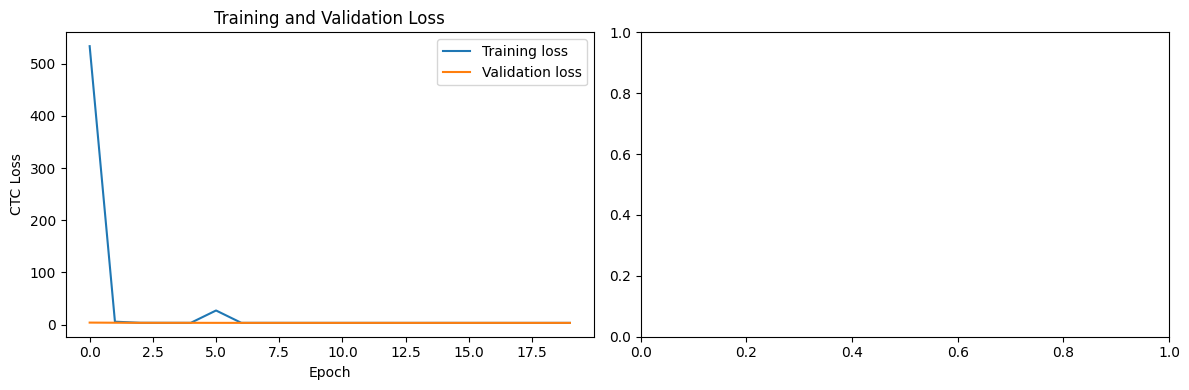

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(train_epoch_losses, label="Training loss")
axes[0].plot(val_epoch_losses, label="Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CTC Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()

# PER plot
if compute_per == True:
    train_epoch_PERs_percent = [per * 100 for per in train_epoch_PERs]
    val_epoch_PERs_percent = [per * 100 for per in val_epoch_PERs]
    axes[1].plot(train_epoch_PERs_percent, label="Training PER")
    axes[1].plot(val_epoch_PERs_percent, label="Validation PER")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("PER (%)")
    axes[1].set_title("Training and Validation PER")
    axes[1].legend()

fig.tight_layout()
plt.show()

In [ ]:
min_train_epoch_loss = min(train_epoch_losses)
min_val_epoch_loss = min(val_epoch_losses)

experiment_config = {
    # training loop
    "epochs": epochs,
    "use_scheduler": use_scheduler,
    "training_start_time": training_start_time,
    "training_end_time": training_end_time,
    "elapsed_time_minutes": elapsed_time,
    "min_train_epoch_loss": min_train_epoch_loss,
    "min_val_epoch_loss": min_val_epoch_loss,
    

    "batch_size": batch_size,
    "seed": seed,

    # Dataset settings
    "padding_after_mel_transform": padding_after_mel_transform,
    "collate_function": collate_function,

    # mel spectrogram settings
    "mel_transform_n_mels": mel_transform_n_mels,
    "mel_transform_nfft": mel_transform_nfft,
    "mel_transform_hop_length": mel_transform_hop_length,
    "mel_transform_win_length": mel_transform_win_length,
    "mel_transform_sample_rate": mel_transform_sample_rate,

    # model settings
    "model_info": model_dict,
    
    # model settings - V3 only
    "num_of_linear_layers": num_of_linear_layers,
    "linear_in_features": linear_in_features,
    "linear_out_features": linear_out_features,
    "linear_dropout": linear_dropout,
    "last_linear_output": last_linear_output,
    
    # loss settings
    "ctc_zero_infinity": ctc_zero_infinity,
    "blank_index": 0,

    # optimizer settings
    "optimizer": optimizer_dict,

    # scheduler settings
    "scheduler_name": scheduler_type,
    "StepLR_scheduler_step_size": StepLR_scheduler_step_size,
    "StepLR_scheduler_gamma": StepLR_scheduler_gamma,
    "Plateau_scheduler_mode": plateau_scheduler_mode,
    "Plateau_scheduler_factor": plateau_scheduler_factor,
    "Plateau_scheduler_patience": plateau_scheduler_patience,
    "Plateau_scheduler_threshold": plateau_scheduler_threshold,
    "Plateau_scheduler_minlr": plateau_scheduler_minlr,

    # gradient_clipping
    "use_gradient_clipping": use_gradient_clipping,

    # vocabulary
    "phoneme_to_idx_vocab": phoneme_to_idx_vocab,
}

losses_and_accuracies_config = {
    "train_epoch_losses": train_epoch_losses,
    "train_epoch_accuracies": train_epoch_PERs,
    "val_epoch_losses": val_epoch_losses,
    "val_epoch_accuracies": val_epoch_PERs,
}

In [12]:
###### SAVE THE RESULTS #####
result_dir = save_training_result(
    figures=fig,
    model=ssm_model,
    config=experiment_config,
    base_results_dir=base_results_dir,
    log_files=[
        log_file_loss_and_PER_path,
        log_file_predictions_path
    ]
)

losses_and_accuracies_path = Path(result_dir) / "losses_and_accuracies.json"
with open(losses_and_accuracies_path, "w") as f:
    json.dump(losses_and_accuracies_config, f, indent=4)

print(f"✅ Saved training results to: {result_dir}")

✅ Saved training results to: /content/drive/MyDrive/thesis/results/result_0


In [ ]:
####### INFERECE and FEATURE MAPS ######

# Path relative to /content/drive/MyDrive/thesis
# Example:
# path_to_weights = "/results/SSM_V5/experiment_01"
path_to_weights = "SSM_result_6_best_val_loss"

if colab:
    weights_path = f"/content/drive/MyDrive/thesis/{path_to_weights}/ssm_model_state_dict.pt"
else:
    weights_path = f"{project_root_dir}/results/{path_to_weights}/ssm_model_state_dict.pt"

print("Loading weights from:")
print(weights_path)

###############################################################
# Check that the weight file exists
if not os.path.exists(weights_path):
    raise FileNotFoundError(
        f"Model weights could not be found:\n{weights_path}"
    )

###############################################################
# Load trained weights into the already instantiated model
state_dict = torch.load(
    weights_path,
    map_location=device
)

ssm_model.load_state_dict(state_dict)

# Move model to selected device and switch to evaluation mode
ssm_model = ssm_model.to(device)
ssm_model.eval()

print("✅ Trained model weights loaded successfully.")


###############################################################
# Register forward hooks on all SSM layers
ssm_model.register_feature_hooks()


###############################################################
# Storage for the complete validation set
validation_feature_maps = []
validation_feature_lengths = []
validation_mel_spectrograms = [] # for saving the avrage energy produced by a frequency bin over the time interval of the hop length

################################################################
# CTC inference results for every validation recording
validation_predictions = []
validation_targets = []
validation_aligned_predictions = []
validation_aligned_targets = []
validation_inference_statistics = []
validation_frame_prediction_ids = []


###############################################################
# Run inference over ALL batches of the validation DataLoader

with torch.inference_mode():

    for batch_index, (
        X_val,
        X_val_length,
        y_val,
        y_val_length
    ) in enumerate(val_dataloader):

        target_offset = 0

        # Move model input to device
        X_val = X_val.to(device)

        ########################################################
        # Forward pass
        #
        # The registered hooks automatically capture the output
        # of every SSM layer for this batch.

        logits = ssm_model(X_val)


        # for safety -> output length of the logits
        if ssm_model_version == "V5":
            batch_output_lengths = (
                ssm_model.calculate_output_lengths(
                    X_val_length
                )
            )
        else:
            batch_output_lengths = X_val_length
        ########################################################
        # Go through every recording in this batch separately

        batch_size = X_val.shape[0]

        for sample_in_batch in range(batch_size):

            # Number of VALID Mel time frames for this recording
            valid_length = int(
                X_val_length[sample_in_batch].item()
            )

            target_length = int(
                y_val_length[sample_in_batch].item()
            )

            sample_target_ids = y_val[
                target_offset:
                target_offset + target_length
            ]

            target_offset += target_length

            sample_target_ids = (
                sample_target_ids
                .detach()
                .cpu()
                .tolist()
            )

            target_phonemes = [
                idx_to_phoneme_vocab[target_id]
                for target_id in sample_target_ids
            ]

            valid_output_length = int(
                batch_output_lengths[sample_in_batch].item()
            )

            sample_logits = logits[
                sample_in_batch,
                :valid_output_length,
                :
            ]

            prediction_ids = torch.argmax(
                sample_logits,
                dim=-1
            ).detach().cpu().tolist()

            decoded_ids = ctc_greedy_decode_ids(
                prediction_ids,
                blank_index=0
            )

            predicted_phonemes = [
                idx_to_phoneme_vocab[prediction_id]
                for prediction_id in decoded_ids
            ]

            (
                aligned_predictions,
                aligned_targets,
                operation_counts
            ) = align_phoneme_sequences(
                predicted=predicted_phonemes,
                target=target_phonemes
            )

            validation_predictions.append(
                predicted_phonemes
            )

            validation_targets.append(
                target_phonemes
            )

            validation_aligned_predictions.append(
                aligned_predictions
            )

            validation_aligned_targets.append(
                aligned_targets
            )

            validation_inference_statistics.append(
                operation_counts
            )

            validation_frame_prediction_ids.append(
                prediction_ids
            )

            ###############################################
            # Store the feature maps of this recording
            sample_feature_maps = {}

            for layer_name, feature_map in (
                ssm_model.feature_maps.items()
            ):

                # feature_map:
                #
                # [B, T_max, d_out]
                #
                # Select one recording and remove the padded
                # time region:
                #
                # [valid_length, d_out]

                sample_feature_maps[layer_name] = (
                    feature_map[
                        sample_in_batch,
                        :valid_length,
                        :
                    ]
                    .detach()
                    .cpu()
                    .clone()
                )

            ########################################################
            # Store the valid Mel spectrogram of this recording
            #
            # X_val shape:
            # [B, T_max, 80]
            #
            # After selecting one recording and removing padding:
            # [valid_length, 80]

            sample_mel_spectrogram = (
                X_val[
                    sample_in_batch,
                    :valid_length,
                    :
                ]
                .detach()
                .cpu()
                .clone()
            )

            validation_mel_spectrograms.append(
                sample_mel_spectrogram
            )

            # Store this recording
            validation_feature_maps.append(
                sample_feature_maps
            )

            validation_feature_lengths.append(
                valid_length
            )


        print(
            f"Processed batch "
            f"{batch_index + 1}/{len(val_dataloader)}"
        )


###############################################################
# Calculate valid output lengths
#
# V5 contains the Conv1d frontend, therefore the waveform
# lengths must be converted to the sequence lengths seen by
# the SSM layers.
if ssm_model_version == "V5":
    output_lengths = ssm_model.calculate_output_lengths(
        X_val_length
    )
else:
    output_lengths = X_val_length


################################################################
# Print the shape of the output and the feature map tensors
print("\nModel output shape:")
print(logits.shape)

print("\nCaptured SSM feature maps:")

for layer_name, feature_map in ssm_model.feature_maps.items():

    print(
        f"{layer_name}: {feature_map.shape}"
    )


###############################################################
# hooks are no longer necessary after this inference pass.
#
# Removing the hooks -> does not remove the extracted feature maps
ssm_model.remove_feature_hooks()

print("\n✅ Feature maps captured successfully.")

Loading weights from:
/Users/atis/Desktop/MasterArbeit/Code/results/SSM_result_6_best_val_loss/ssm_model_state_dict.pt
✅ Trained model weights loaded successfully.
Processed batch 1/210
Processed batch 2/210
Processed batch 3/210
Processed batch 4/210
Processed batch 5/210
Processed batch 6/210
Processed batch 7/210
Processed batch 8/210
Processed batch 9/210
Processed batch 10/210
Processed batch 11/210
Processed batch 12/210
Processed batch 13/210
Processed batch 14/210
Processed batch 15/210
Processed batch 16/210
Processed batch 17/210
Processed batch 18/210
Processed batch 19/210
Processed batch 20/210
Processed batch 21/210
Processed batch 22/210
Processed batch 23/210
Processed batch 24/210
Processed batch 25/210
Processed batch 26/210
Processed batch 27/210
Processed batch 28/210
Processed batch 29/210
Processed batch 30/210
Processed batch 31/210
Processed batch 32/210
Processed batch 33/210
Processed batch 34/210
Processed batch 35/210
Processed batch 36/210
Processed batch 3

Selected sample: TEST/DR1/FAKS0/SI2203
Audio file: /Users/atis/Desktop/MasterArbeit/Code/TIMIT/data/TEST/DR1/FAKS0/SI2203.WAV
Phoneme file: /Users/atis/Desktop/MasterArbeit/Code/TIMIT/data/TEST/DR1/FAKS0/SI2203.PHN
Selected recording feature-map shape: torch.Size([352, 128])

Per-phoneme Mel statistics:

h# | 0.0 - 0.599 s | frames: 60 | strongest Mel bin: 65 | average value: 0.27
dh | 0.599 - 0.615 s | frames: 2 | strongest Mel bin: 17 | average value: 7.096
ix | 0.615 - 0.666 s | frames: 5 | strongest Mel bin: 15 | average value: 12.592
r | 0.666 - 0.75 s | frames: 8 | strongest Mel bin: 15 | average value: 9.198
iy | 0.75 - 0.915 s | frames: 17 | strongest Mel bin: 10 | average value: 10.566
z | 0.915 - 1.021 s | frames: 11 | strongest Mel bin: 68 | average value: 10.17
ax | 1.021 - 1.047 s | frames: 2 | strongest Mel bin: 18 | average value: 9.67
n | 1.047 - 1.196 s | frames: 15 | strongest Mel bin: 17 | average value: 8.905
z | 1.196 - 1.315 s | frames: 12 | strongest Mel bin: 69 

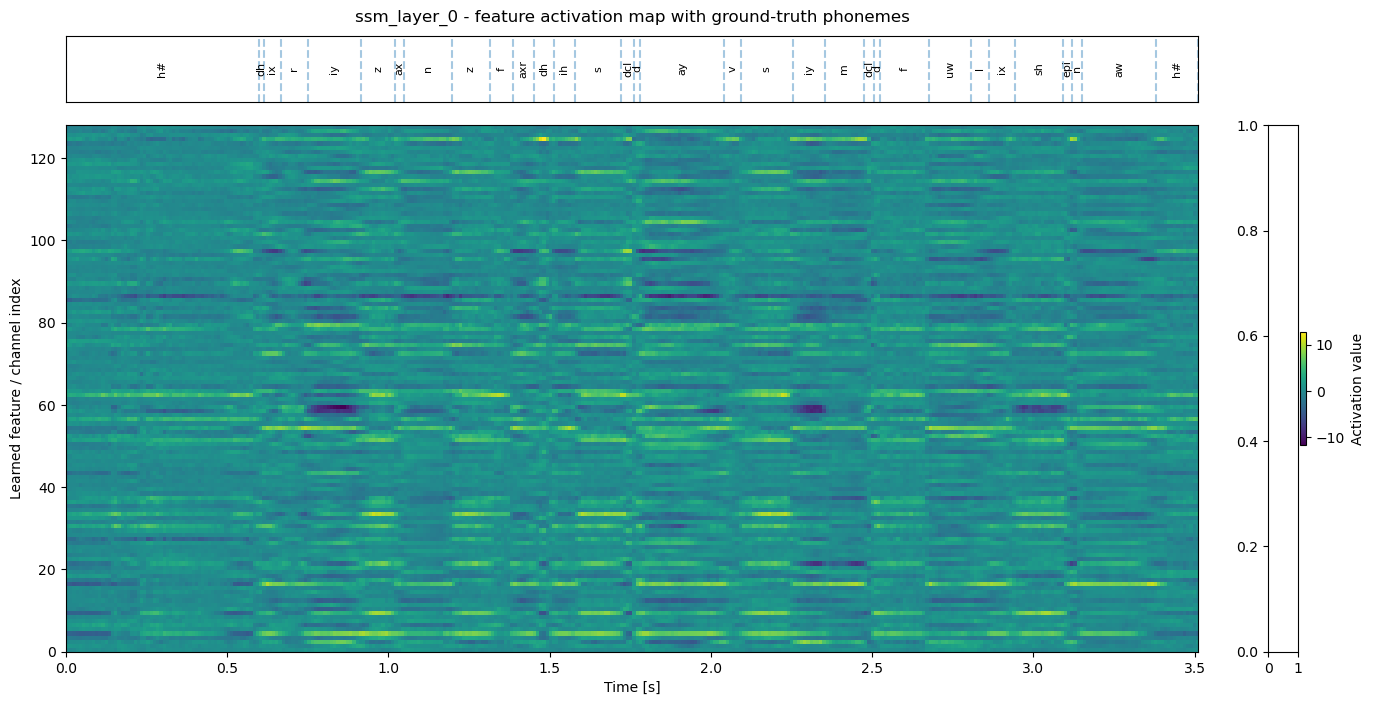


Phoneme intervals:
  h# : 0.000 s → 0.599 s
  dh : 0.599 s → 0.615 s
  ix : 0.615 s → 0.666 s
   r : 0.666 s → 0.750 s
  iy : 0.750 s → 0.915 s
   z : 0.915 s → 1.021 s
  ax : 1.021 s → 1.047 s
   n : 1.047 s → 1.196 s
   z : 1.196 s → 1.315 s
   f : 1.315 s → 1.387 s
 axr : 1.387 s → 1.452 s
  dh : 1.452 s → 1.514 s
  ih : 1.514 s → 1.577 s
   s : 1.577 s → 1.722 s
 dcl : 1.722 s → 1.762 s
   d : 1.762 s → 1.780 s
  ay : 1.780 s → 2.041 s
   v : 2.041 s → 2.092 s
   s : 2.092 s → 2.254 s
  iy : 2.254 s → 2.353 s
   m : 2.353 s → 2.475 s
 dcl : 2.475 s → 2.506 s
   d : 2.506 s → 2.523 s
   f : 2.523 s → 2.677 s
  uw : 2.677 s → 2.806 s
   l : 2.806 s → 2.861 s
  ix : 2.861 s → 2.943 s
  sh : 2.943 s → 3.092 s
 epi : 3.092 s → 3.120 s
   n : 3.120 s → 3.150 s
  aw : 3.150 s → 3.380 s
  h# : 3.380 s → 3.510 s


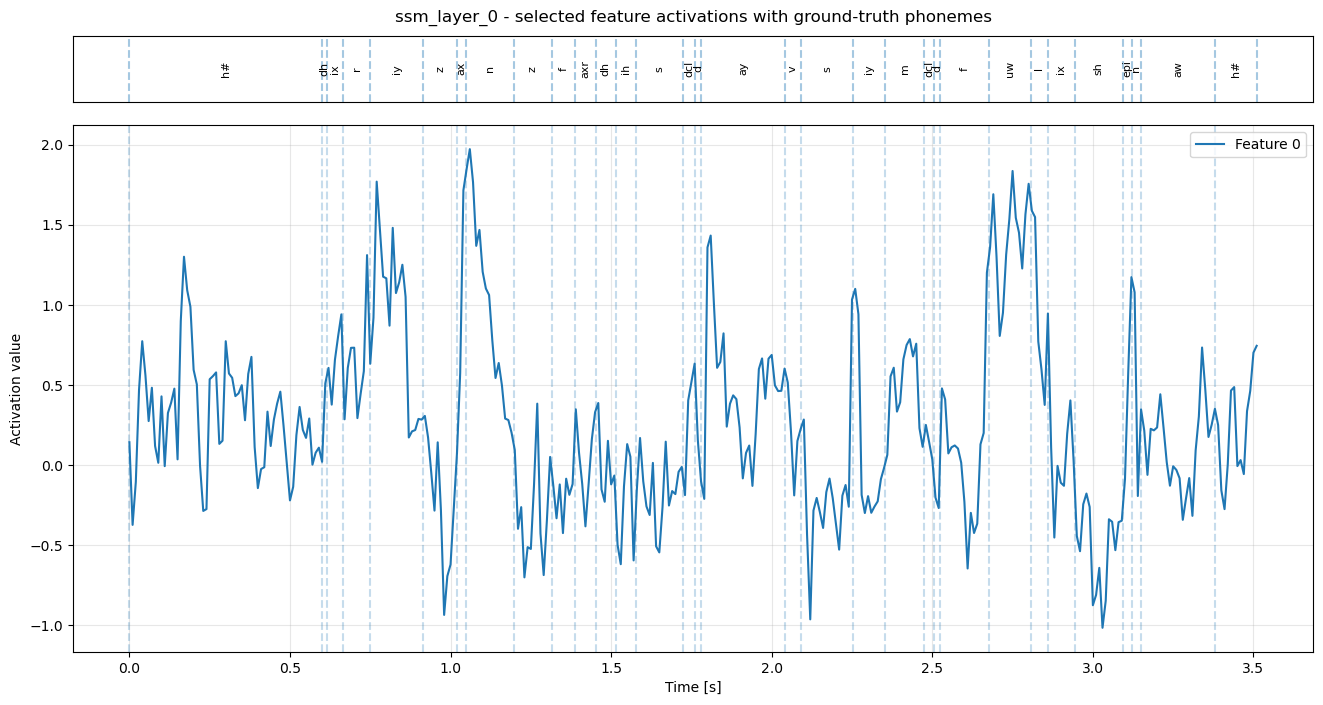

In [18]:
# ============================================================
# VISUALIZE SSM FEATURE MAPS
# ============================================================

# Which recording from the validation batch should be shown?
sample_index = 3

# Which SSM layer should be inspected?
# Available for a 4-layer model:
# "ssm_layer_0"
# "ssm_layer_1"
# "ssm_layer_2"
# "ssm_layer_3"
selected_layer = "ssm_layer_0"

# Which individual learned features should be plotted as single curves?
selected_features = [0]


# ------------------------------------------------------------
# Get feature map of selected layer
#
# Shape:
#   [batch, time, features]
# ------------------------------------------------------------
sample_feature_map = (
    validation_feature_maps[sample_index][selected_layer]
)


# ------------------------------------------------------------
# Get the log-mel spectrogram of the time domain audio
#
# Shape:
#   [batch, time, features]
# ------------------------------------------------------------
# the spectrogram of the time domain audio
sample_mel_spectrogram = validation_mel_spectrograms[sample_index]


# ------------------------------------------------------------
# Get the phonemes and their intervals in seconds of the current sample
# ------------------------------------------------------------
phn_file_path = (
    val_dataset.samples[sample_index]["phoneme_path"]
)

sample_name = (
    val_dataset.samples[sample_index]["base_name"]
)

audio_file_path = (
    val_dataset.samples[sample_index]["audio_path"]
)

phn_file_path = (
    val_dataset.samples[sample_index]["phoneme_path"]
)

target_phonemes = (
    validation_targets[sample_index]
)

predicted_phonemes = (
    validation_predictions[sample_index]
)

aligned_targets = (
    validation_aligned_targets[sample_index]
)

aligned_predictions = (
    validation_aligned_predictions[sample_index]
)

inference_statistics = (
    validation_inference_statistics[sample_index]
)

print("Selected sample:", sample_name)
print("Audio file:", audio_file_path)
print("Phoneme file:", phn_file_path)

phoneme_intervals = load_phoneme_intervals(
    phn_file_path,
    sample_rate=mel_transform_sample_rate
)

print(
    "Selected recording feature-map shape:",
    sample_feature_map.shape
)


# ------------------------------------------------------------
# Number of valid time steps
#
# Padding was already removed during inference.
# ------------------------------------------------------------

valid_length = sample_feature_map.shape[0]


# ------------------------------------------------------------
# Calculate approximate time axis
#
# V5 Conv1d stride = 160 samples.
# At 16 kHz this corresponds to approximately 10 ms
# between consecutive SSM input/output positions.
# ------------------------------------------------------------
if ssm_model_version == "V5":

    total_stride = np.prod(conv_strides)

    time_step_seconds = (
        total_stride /
        mel_transform_sample_rate
    )

else:
    # how much time jump between consecutive mel frames
    time_step_seconds = (
        mel_transform_hop_length /
        mel_transform_sample_rate
    )


time_axis = (
    np.arange(valid_length) *
    time_step_seconds
)


# ============================================================
# 1. COMPLETE SSM FEATURE MAP WITH PHONEME STRIP
# ============================================================

fig = plt.figure(
    figsize=(16, 8)
)

gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[1, 8],
    width_ratios=[30, 1],
    hspace=0.08,
    wspace=0.12
)

# Top-left: phoneme strip
ax_phoneme = fig.add_subplot(
    gs[0, 0]
)

# Bottom-left: feature map
ax_map = fig.add_subplot(
    gs[1, 0],
    sharex=ax_phoneme
)

# Bottom-right: colorbar
ax_colorbar = fig.add_subplot(
    gs[1, 1]
)


#############################################
# Calculate the frequency domain log-mel statistics of the mel transformed audio sequence
phoneme_mel_statistics = (
    calculate_phoneme_mel_statistics(
        sample_mel_spectrogram,
        phoneme_intervals,
        hop_length=mel_transform_hop_length,
        sample_rate=mel_transform_sample_rate
    )
)

#############################################
# Print the frequency domain  log-mel statistics of the mel trasnformed audio sequence
print("\nPer-phoneme Mel statistics:\n")

for stats in phoneme_mel_statistics:

    print(
        stats["phoneme"],
        "|",
        round(stats["start_time"], 3),
        "-",
        round(stats["end_time"], 3),
        "s | frames:",
        stats["number_of_frames"],
        "| strongest Mel bin:",
        stats["strongest_mel_bin"],
        "| average value:",
        round(stats["strongest_average_value"], 3)
    )


print("\nPHONEME INFERENCE")
print("=================\n")

for index, (
    target,
    prediction
) in enumerate(
    zip(
        aligned_targets,
        aligned_predictions
    )
):

    if target == prediction:
        status = "CORRECT"

    elif target == "-":
        status = "INSERTION"

    elif prediction == "-":
        status = "DELETION"

    else:
        status = "SUBSTITUTION"

    print(
        f"{index:3d} | "
        f"TGT: {target:5s} | "
        f"PRED: {prediction:5s} | "
        f"{status}"
    )

# ------------------------------------------------------------
# 1. PHONEME STRIP
# ------------------------------------------------------------

for interval in phoneme_intervals:

    start_time = interval["start_time"]
    end_time = interval["end_time"]
    phoneme = interval["phoneme"]

    center_time = (start_time + end_time) / 2

    # Draw phoneme boundaries
    ax_phoneme.axvline(
        start_time,
        linestyle="--",
        alpha=0.4
    )

    # Write phoneme in the middle of its interval
    ax_phoneme.text(
        center_time,
        0.5,
        phoneme,
        horizontalalignment="center",
        verticalalignment="center",
        rotation=90,
        fontsize=8
    )


# final boundary
if len(phoneme_intervals) > 0:
    ax_phoneme.axvline(
        phoneme_intervals[-1]["end_time"],
        linestyle="--",
        alpha=0.4
    )


# Make phoneme axis only a thin annotation area
ax_phoneme.set_ylim(0, 1)

ax_phoneme.set_yticks([])

ax_phoneme.tick_params(
    axis="x",
    which="both",
    bottom=False,
    labelbottom=False
)

ax_phoneme.set_title(
    f"{selected_layer} - feature activation map with ground-truth phonemes",
    pad=10
)


# ------------------------------------------------------------
# 2. FEATURE MAP
# ------------------------------------------------------------

image = ax_map.imshow(
    sample_feature_map.T.numpy(),
    aspect="auto",
    origin="lower",
    extent=[
        time_axis[0],
        time_axis[-1],
        0,
        sample_feature_map.shape[1]
    ]
)

fig.colorbar(
    image,
    ax=ax_colorbar,
    label="Activation value"
)

ax_map.set_xlabel("Time [s]")
ax_map.set_ylabel("Learned feature / channel index")

plt.show()

# ============================================================
# 2. PRINT PHONEME INTERVALS
# ============================================================
print("\nPhoneme intervals:")

for interval in phoneme_intervals:

    print(
        f"{interval['phoneme']:>4} : "
        f"{interval['start_time']:.3f} s "
        f"→ "
        f"{interval['end_time']:.3f} s"
    )

# ============================================================
# 3. INDIVIDUAL FEATURE ACTIVATIONS WITH PHONEME STRIP
# ============================================================

fig, (ax_phoneme, ax_features) = plt.subplots(
    2,
    1,
    figsize=(16, 8),
    sharex=True,
    gridspec_kw={
        "height_ratios": [1, 8],
        "hspace": 0.08
    }
)


# ------------------------------------------------------------
# 1. PHONEME STRIP
# ------------------------------------------------------------

for interval in phoneme_intervals:

    start_time = interval["start_time"]
    end_time = interval["end_time"]
    phoneme = interval["phoneme"]

    center_time = (start_time + end_time) / 2

    ax_phoneme.axvline(
        start_time,
        linestyle="--",
        alpha=0.4
    )

    ax_phoneme.text(
        center_time,
        0.5,
        phoneme,
        horizontalalignment="center",
        verticalalignment="center",
        rotation=90,
        fontsize=8
    )


if len(phoneme_intervals) > 0:
    ax_phoneme.axvline(
        phoneme_intervals[-1]["end_time"],
        linestyle="--",
        alpha=0.4
    )


ax_phoneme.set_ylim(0, 1)
ax_phoneme.set_yticks([])

ax_phoneme.tick_params(
    axis="x",
    which="both",
    bottom=False,
    labelbottom=False
)

ax_phoneme.set_title(
    f"{selected_layer} - selected feature activations with ground-truth phonemes",
    pad=10
)


# ------------------------------------------------------------
# 2. FEATURE ACTIVATION CURVES
# ------------------------------------------------------------

for feature_index in selected_features:

    if feature_index >= sample_feature_map.shape[1]:

        print(
            f"Skipping feature {feature_index}: "
            f"{selected_layer} contains only "
            f"{sample_feature_map.shape[1]} features."
        )

        continue

    ax_features.plot(
        time_axis,
        sample_feature_map[:, feature_index].numpy(),
        label=f"Feature {feature_index}"
    )


# ------------------------------------------------------------
# Draw phoneme boundaries also through the feature plot
# ------------------------------------------------------------

for interval in phoneme_intervals:

    ax_features.axvline(
        interval["start_time"],
        linestyle="--",
        alpha=0.25
    )


ax_features.set_xlabel("Time [s]")
ax_features.set_ylabel("Activation value")

ax_features.legend()
ax_features.grid(alpha=0.3)

plt.show()